In [205]:
import importlib
import ToFPipeline.ToFPipeline as ToFPipeline
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # Do NOT use external LaTeX
    "text.usetex": True,

    # All normal text
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    # All math text
    "mathtext.fontset": "cm",
})


In [207]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
runNo=2119

In [132]:
raw = """
> |Photon Energy|daq_run|Ugap|Ushift
> |1300|2119|29.673|14
> |1300|2120|28.224|17
> |1300|2121|26.669|20
> |1300|2122|25.169|23
> |1290|2123|29.575|14
> |1290|2124|28.13|17
> |1290|2125|26.579|20
> |1290|2126|25.083|23
> |1280|2127|29.478|14
> |1280|2128|28.034|17
> |1280|2129|26.489|20
> |1280|2130|24.999|23
> |1270|2131|29.378|14
> |1270|2132|27.938|17
> |1270|2133|26.399|20
> |1270|2134|24.913|23
> |1260|2135|29.28|14
> |1260|2136|27.843|17
> |1260|2137|26.308|20
> |1260|2138|24.827|23
> |1250|2139|29.179|14
> |1250|2140|27.747|17
> |1250|2141|26.216|20
> |1250|2142|24.741|23
> |1240|2143|29.079|14
> |1240|2144|27.649|17
> |1240|2145|26.124|20
> |1240|2146|24.655|23
> |1230|2147|28.979|14
> |1230|2148|27.552|17
> |1230|2149|26.03|20
> |1230|2150|24.567|23
> |1230|2152|28.979|14
> |1230|2153|27.552|17
> |1230|2154|26.03|20
> |1230|2155|24.567|23
> |1220|2156|28.878|14
> |1220|2157|27.454|17
> |1220|2158|25.938|20
> |1220|2159|24.479|23
> |1210|2160|28.776|14
> |1210|2161|27.356|17
> |1210|2162|25.845|20
> |1210|2163|24.392|23
> |1200|2164|28.673|14
> |1200|2165|27.257|17
> |1200|2166|25.751|20
> |1200|2167|24.304|23
> |1190|2168|28.569|14
> |1190|2169|27.157|17
> |1190|2170|25.655|20
> |1190|2171|24.216|23
> |1180|2172|28.466|14
> |1180|2173|27.058|17
> |1180|2174|25.56|20
> |1180|2175|24.126|23
> |1170|2176|28.362|14
> |1170|2177|26.956|17
> |1170|2178|25.464|20
> |1170|2179|24.036|23
> |1160|2180|28.257|14
> |1160|2181|26.854|17
> |1160|2182|25.368|20
> |1160|2183|23.946|23
> |1150|2184|28.151|14
> |1150|2185|26.753|17
> |1150|2186|25.271|20
> |1150|2187|23.854|23
> |1140|2188|28.046|14
> |1140|2189|26.651|17
> |1140|2190|25.175|20
> |1140|2191|23.763|23
> |1130|2192|27.938|14
> |1130|2193|26.548|17
> |1130|2194|25.075|20
> |1130|2195|23.671|23
> |1120|2196|27.831|14
> |1120|2197|26.444|17
> |1120|2198|24.978|20
> |1120|2199|23.579|23
> |1110|2200|27.722|14
> |1110|2201|26.341|17
> |1110|2202|24.878|20
> |1110|2203|23.485|23
> |1100|2204|27.614|14
> |1100|2205|26.235|17
> |1100|2206|24.778|20
> |1100|2207|23.392|23
> |1090|2208|27.503|14
> |1090|2209|26.13|17
> |1090|2210|24.679|20
> |1090|2211|23.298|23
> |1080|2212|27.394|14
> |1080|2213|26.022|17
> |1080|2214|24.577|20
> |1080|2215|23.204|23
> |1070|2216|27.282|14
> |1070|2217|25.915|17
> |1070|2218|24.476|20
> |1070|2219|23.108|23
> |1060|2220|27.171|14
> |1060|2221|25.808|17
> |1060|2222|24.374|20
> |1060|2223|23.013|23
> |1050|2224|27.058|14
> |1050|2225|25.7|17
> |1050|2226|24.271|20
> |1050|2227|22.915|23
> |1040|2228|26.944|14
> |1040|2229|25.591|17
> |1040|2230|24.167|20
> |1040|2231|22.819|23
> |1030|2232|26.829|14
> |1030|2233|25.479|17
> |1030|2234|24.062|20
> |1030|2235|22.72|23
> |1020|2236|26.714|14
> |1020|2237|25.37|17
> |1020|2238|23.958|20
> |1020|2239|22.622|23
> |1010|2240|26.599|14
> |1010|2241|25.257|17
> |1010|2242|23.851|20
> |1010|2243|22.522|23
> |1000|2244|26.481|14
> |1000|2245|25.146|17
> |1000|2246|23.745|20
> |1000|2247|22.423|23
"""

In [208]:
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[0,10]).sampleShift()

In [209]:
#%matplotlib widget
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[0,10])
results = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize().process(threshold=0.01,peakNo=1,roi=[0,700],minWidth=False,symmetric=False,slopeLength=False, slopeStartHeight=False).dataframe()
results.results["pos"] = results.results["pos"] + 0
#results.fitGaussians(useUpperHalf=False, roiWidthMultiplier=3.0)
#results.plotSingle(ToF=0,xmin=280,xmax=480,figsize=(4,5),showGaussianFit=False)


Random trainId: 2119, pulseId: 0


Random trainId: 2119, pulseId: 0


Random trainId: 2119, pulseId: 0


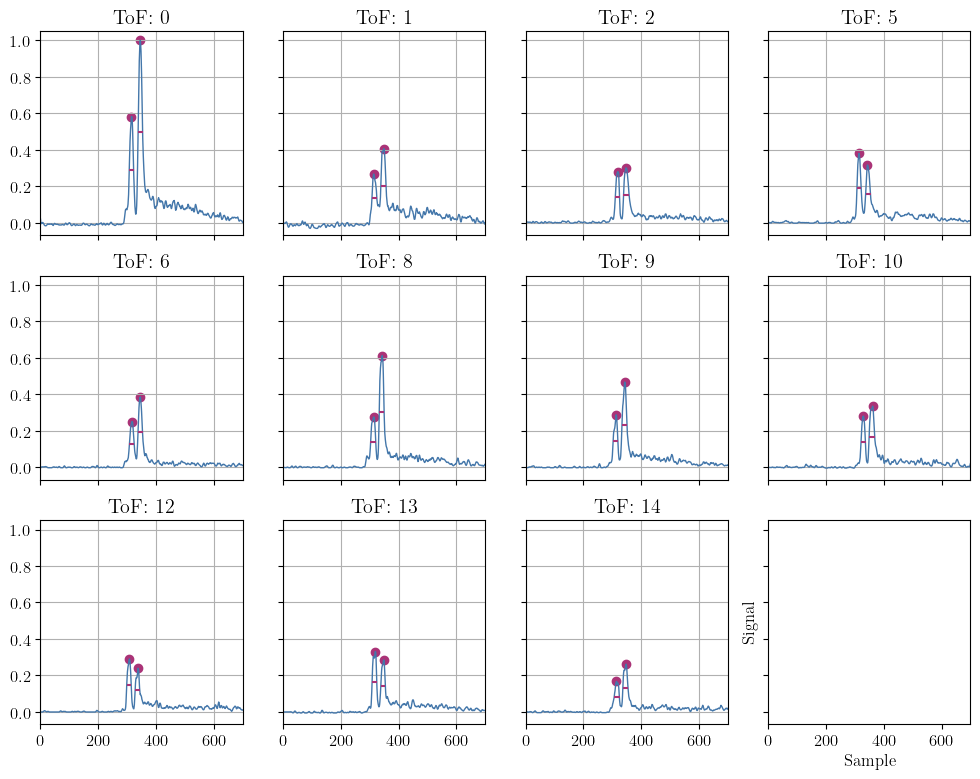

In [210]:
results.plot(xmin=0,xmax=700,logScale=False, raw=False)

In [211]:
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
import pandas as pd
results.results["Photon Energy"] = 1000

In [212]:
import numpy as np
def computeCorr(theta,I, Plin, phi=0, beta=2):
    return I/(1 + (beta / 4) * (1 + 3 * Plin * np.cos(2 * (theta - phi))))

In [213]:
def computePlin(theta, I0, I1, beta1, beta2, phi=0):
    return (4 / (3 * np.cos(2*(theta - phi)))) * ((I1 * (1 + beta1/4) - I0 * (1 + beta2/4)) / (I0 * beta2 - I1 * beta1))

In [214]:
# Separate peaks into different columns
peak0 = results.results[results.results['peakNo']==0].set_index(['detector', 'trainId', 'pulseId'])
peak1 = results.results[results.results['peakNo']==1].set_index(['detector', 'trainId', 'pulseId'])

# Merge on common indices
merged = results.results.merge(
    peak0[['height']].rename(columns={'height': 'I0'}),
    left_on=['detector', 'trainId', 'pulseId'],
    right_index=True,
    how='left'
).merge(
    peak1[['height']].rename(columns={'height': 'I1'}),
    left_on=['detector', 'trainId', 'pulseId'],
    right_index=True,
    how='left'
)

# Now compute Plin with aligned data
merged['Plin'] = computePlin(
    theta=merged['Angles'],
    I0=merged['I0'],
    I1=merged['I1'],
    beta1=0,
    beta2=1.357
)

In [215]:
merged["Transmission coefficent"] = computeCorr(
    merged['Angles'],merged['I0'],
    merged['Plin'],phi=0,beta=1.357)
corr_calc = merged[merged['peakNo']==0][["detector","Photon Energy","Transmission coefficent"]].reset_index()


In [216]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")

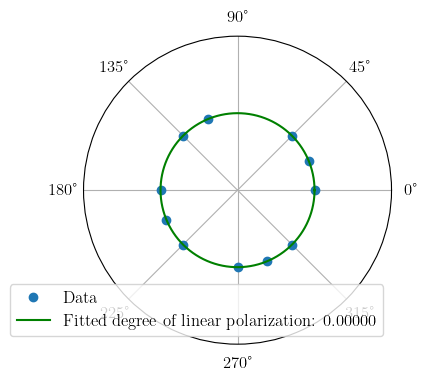

(array([ 2.61248515e-10, -1.36090075e+00,  1.00000000e+00]),
 array([[8.53134901e-21, 0.00000000e+00, 7.08237005e-22],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.08237005e-22, 0.00000000e+00, 5.16134337e-21]]))

In [217]:
beta=2
peakNo=1
method = "height"
calib = ToFPipeline.Calibrate(results.results).transmission(peakNo=peakNo,setBeta=beta,setPlin=0.00,setPhi=0,intMethod=method).transmissionParam
ToFPipeline.Fitter(results.results).pol(transParam=calib,peakNo=peakNo,beta=beta,intMethod=method)

In [218]:
import pandas as pd
from io import StringIO
rawdf = pd.read_csv(StringIO(raw), sep="|", skiprows=1).dropna().astype({"Photon Energy":int,"daq_run":int,"Ugap":float,"Ushift":float})
rawdf = rawdf[["daq_run","Photon Energy","Ugap","Ushift"]]

In [219]:
#%matplotlib widget
peakNo=1
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2119],roi=[0,500]).defaultPreprocessing(baselineRegion=[0,10]).sampleShift()
results = ToFPipeline.PeakFinder(data.data).stack().smooth().normalize().process(threshold=0.01,peakNo=peakNo,roi=[None,500],minWidth=False,symmetric=False).dataframe()#.plot(logScale=False,xmin=250,xmax=400)

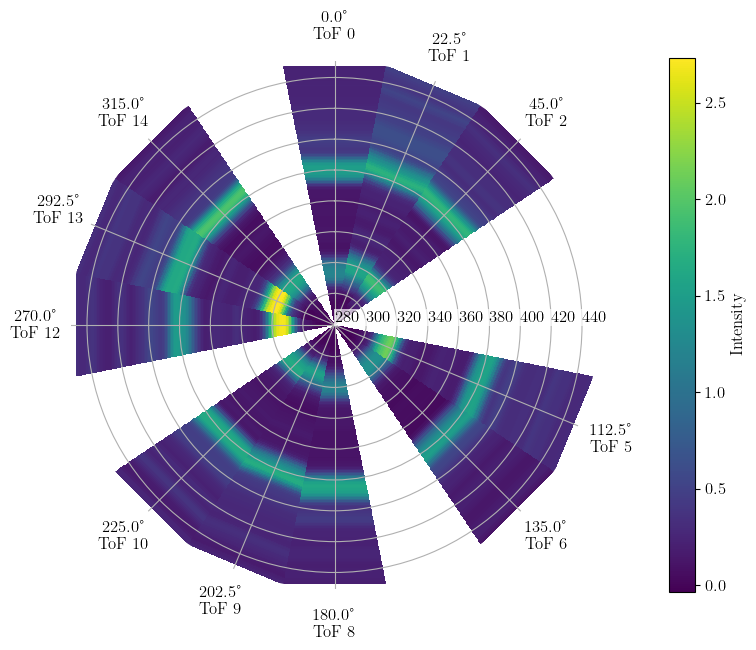

In [265]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
plotdata = ToFPipeline.NXSLoader("data").load(runNumbers=[2200]).defaultPreprocessing(baselineRegion=[0,10]).data
stack = ToFPipeline.PeakFinder(plotdata).stack().smooth().smooth().smooth().normalize()
res = ToFPipeline.PeakFinder(plotdata).stack().smooth().smooth().smooth().normalize().process().dataframe()
plotter = ToFPipeline.Plotter(data = stack.data)
plotter.plot(transParam=calib,sampleMin=280, sampleMax=450, interpolate=False)

In [266]:
t0 = res.results[res.results["peakNo"] == 1]
t0["pos"] = t0["pos"] - 385
t0[["detector","pos"]]

C:\Users\mogilows\AppData\Local\Temp\ipykernel_22020\4033608202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t0["pos"] = t0["pos"] - 385


C:\Users\mogilows\AppData\Local\Temp\ipykernel_22020\4033608202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t0["pos"] = t0["pos"] - 385


,detector,pos
1,0,-1.0
3,1,0.0
5,2,-1.0
7,5,-1.0
9,6,-1.0
11,8,1.0
13,9,0.0
15,10,-1.0
17,12,-1.0
19,13,1.0


In [148]:
import numpy as np
values=[]
error=[]
energies=[]
daq_run=[]
beta=2
first=True
for i in rawdf["daq_run"].unique():
    runNo = i
    setPhotonEnergy = rawdf[rawdf["daq_run"]==runNo]["Photon Energy"].values
    data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo],roi=[0,700]).defaultPreprocessing(baselineRegion=[0,10])
    results = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize().process(threshold=0.005,peakNo=peakNo,roi=[0,670]).dataframe()
    ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
    runs = runNo
    setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
    runsPhotonEnergy = pd.DataFrame(setEnergyRun)
    results.results["Photon Energy"] = setPhotonEnergy[0]
    popt,pcov = ToFPipeline.Fitter(results.results).pol(calib,peakNo=peakNo,beta=beta,plot=False,intMethod=method)
    values.append(popt)
    perr = np.sqrt(np.diag(pcov))
    error.append(perr)
    energies.append(setPhotonEnergy[0])
    daq_run.append(runNo)
    if first:
        everything = results.results
        first=False
    else:
        everything = pd.concat([everything, results.results], ignore_index=True)
    print(f"Completed run {runNo}")
values=pd.DataFrame(values, columns=["PLin","phi","scale"])
values["Photon Energy"]=energies
values["daq_run"]=daq_run
error=pd.DataFrame(error, columns=["PLin_err","phi_err","scale_err"])
values["PLin_err"]=error["PLin_err"]
values["phi_err"]=error["phi_err"]



Completed run 2119
Completed run 2120
Completed run 2121
Completed run 2122
Completed run 2123
Completed run 2124
Completed run 2125
Completed run 2126
Completed run 2127
Completed run 2128
Completed run 2129
Completed run 2130
Completed run 2131
Completed run 2132
Completed run 2133
Completed run 2134
Completed run 2135
Completed run 2136
Completed run 2137
Completed run 2138
Completed run 2139
Completed run 2140
Completed run 2141
Completed run 2142
Completed run 2143
Completed run 2144
Completed run 2145
Completed run 2146
Completed run 2147
Completed run 2148
Completed run 2149
Completed run 2150
Completed run 2152
Completed run 2153
Completed run 2154
Completed run 2155
Completed run 2156
Completed run 2157
Completed run 2158
Completed run 2159
Completed run 2160
Completed run 2161
Completed run 2162
Completed run 2163
Completed run 2164
Completed run 2165
Completed run 2166
Completed run 2167
Completed run 2168
Completed run 2169
Completed run 2170
Completed run 2171
Completed ru

In [149]:
runTable = rawdf[["daq_run","Ugap","Ushift"]]
complete = values.merge(runTable, on="daq_run")

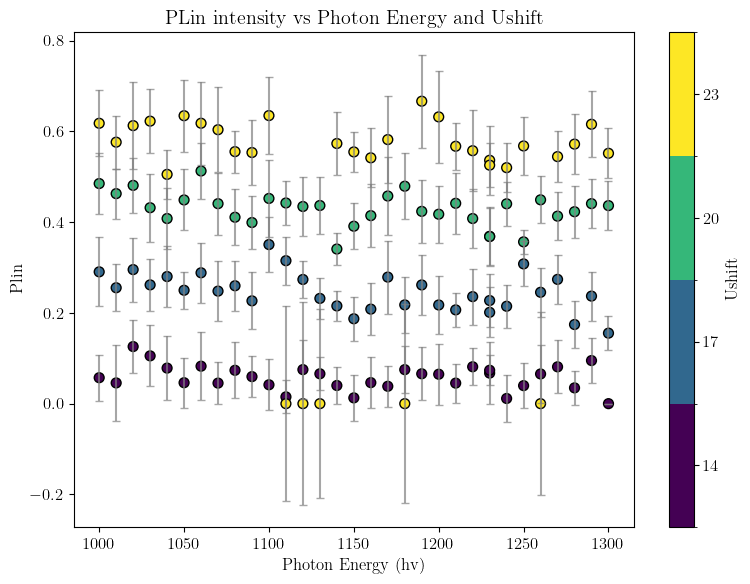

In [150]:
from matplotlib.colors import BoundaryNorm, ListedColormap
fig, ax = plt.subplots(figsize=(8, 6))

# Define the discrete color levels you want
levels = [14, 17, 20, 23]

# Create a colormap with exactly 4 colors
cmap = plt.get_cmap("viridis", len(levels))

# Create a norm that maps your data to the 4 discrete colors
# Boundaries need one more than levels
boundaries = [12.5, 15.5, 18.5, 21.5, 24.5]  # edges around your values
norm = BoundaryNorm(boundaries, cmap.N)

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap=cmap,    # choose any colormap
    norm=norm,
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("Plin")
ax.set_title("PLin intensity vs Photon Energy and Ushift")
#ax.invert_xaxis()  # common in spectroscopy


cbar = plt.colorbar(sc, ax=ax, ticks=levels)
cbar.set_label("Ushift")
plt.tight_layout()
plt.savefig("PLinVsUshift.png",dpi=600)
plt.show()



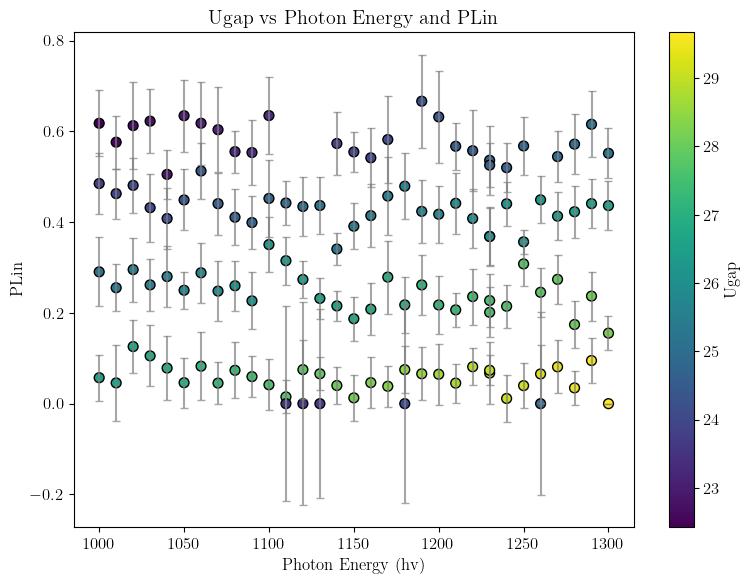

In [151]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ugap"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)
plt.errorbar(
    complete["Photon Energy"],
    complete["PLin"],
    yerr=complete["PLin_err"],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=3
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("PLin")
ax.set_title("Ugap vs Photon Energy and PLin")
#ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ugap")
plt.tight_layout()
plt.show()

Random trainId: 2200, pulseId: 0


Random trainId: 2200, pulseId: 0


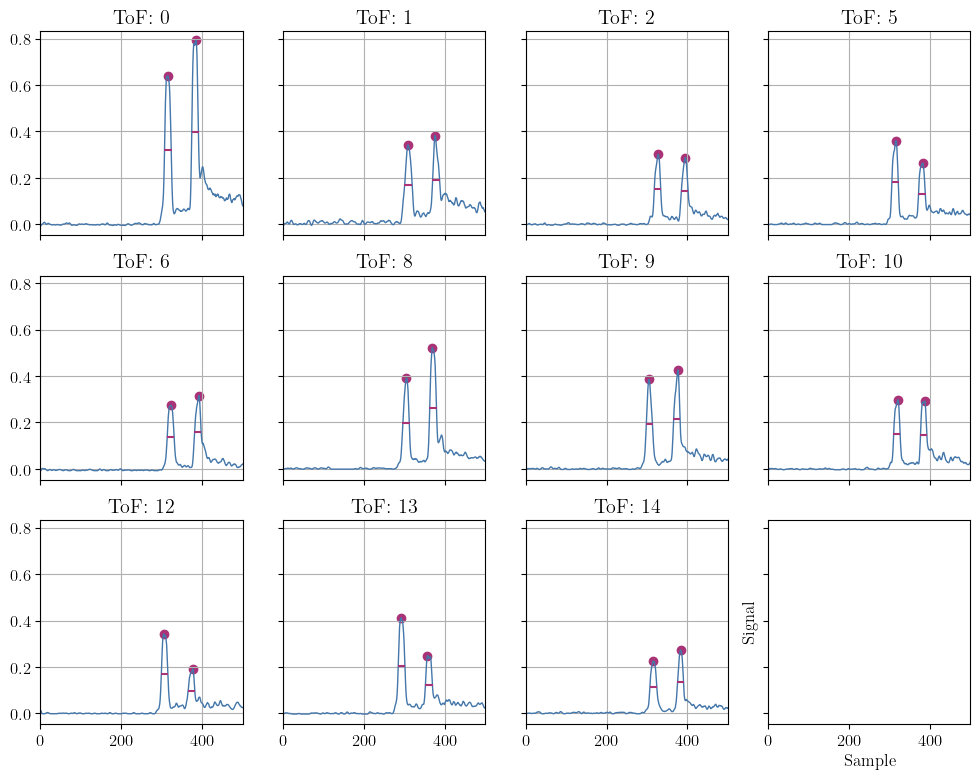

Random trainId: 2200, pulseId: 0


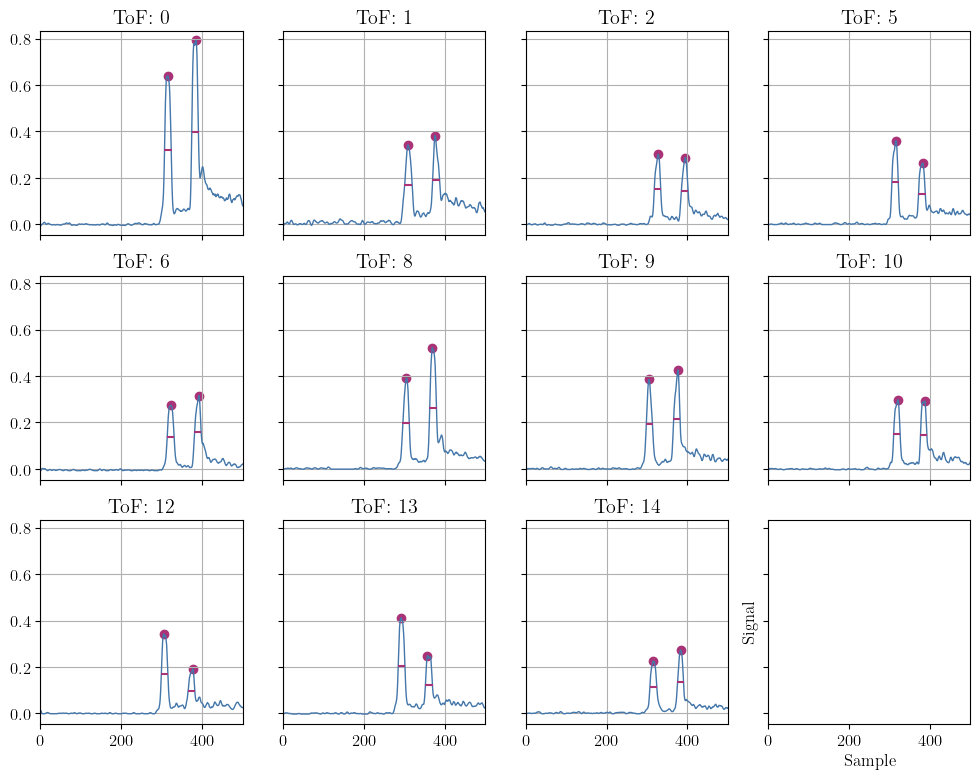

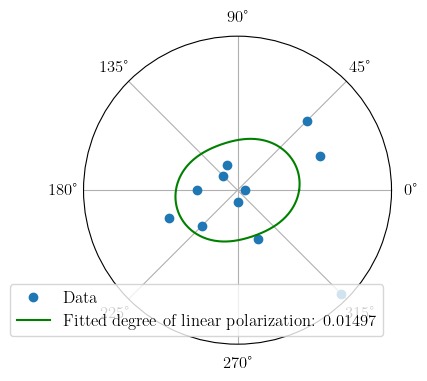

(array([0.01497291, 0.33359383, 0.88015495]),
 array([[ 1.33272473e-03, -1.22721986e-02, -1.12985845e-04],
        [-1.22721986e-02,  2.96226734e+00,  5.15787280e-03],
        [-1.12985845e-04,  5.15787280e-03,  6.68948486e-04]]))

In [152]:
import pandas as pd
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2200]).defaultPreprocessing(baselineRegion=[0,10])
results = ToFPipeline.PeakFinder(data.data).stack().normalize().smooth().smooth().process(threshold=0.01,peakNo=1,roi=[0,700],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=0,xmax=500)
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
results.results["Photon Energy"] = 1000
ToFPipeline.Fitter(results.results).pol(transParam=calib,peakNo=1,beta=2,intMethod="height")

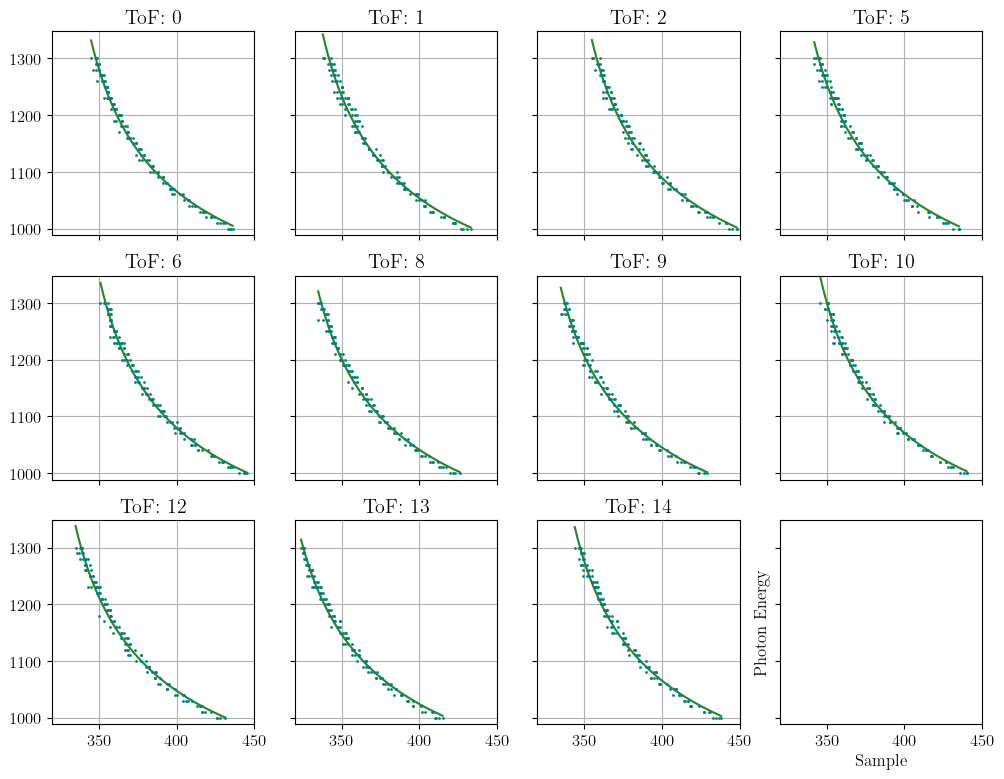

In [156]:

ToFPipeline.Calibrate(everything).energy(relPos=False).plotEnergy(xmin=320,xmax=450)

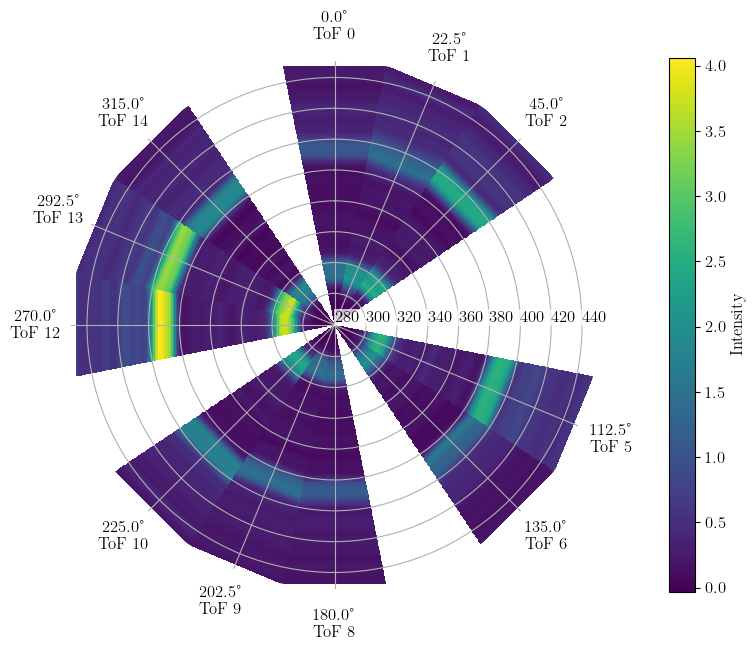

In [463]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("ToFPipeline/config.yaml")
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2219]).defaultPreprocessing(baselineRegion=[0,10])
toPlot = ToFPipeline.PeakFinder(data.data).stack().smooth().smooth().normalize()
results = toPlot.process(threshold=0.01,peakNo=1,roi=[0,700],minWidth=False,symmetric=False,slopeLength=False, slopeStartHeight=False).dataframe()
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
results.results["Photon Energy"] = 1000
plotter = ToFPipeline.Plotter(data = toPlot.data)
plotter.plot(transParam=calib,sampleMin=280, sampleMax=450, interpolate=False)


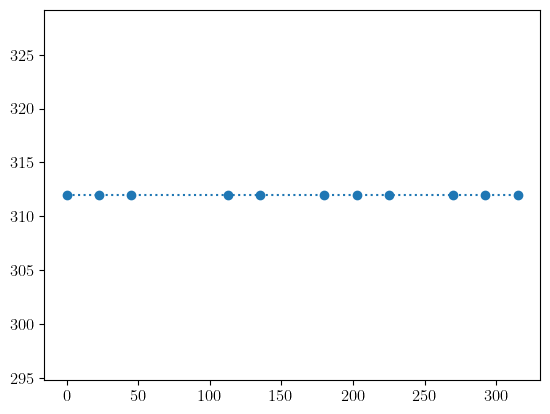

In [464]:
#2119 calib
center=results.results[results.results["peakNo"]==0]
plt.plot(center["Angles"], center["pos"], marker="o", linestyle="dotted")

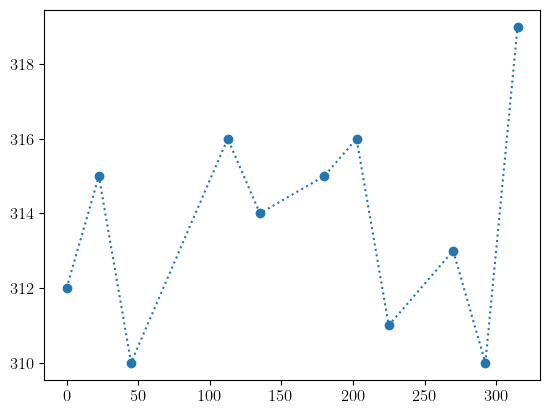

In [438]:
#2219 calib
center=results.results[results.results["peakNo"]==0]
plt.plot(center["Angles"], center["pos"], marker="o", linestyle="dotted")

# Distance Calculation from Signal Center

Two methods to calculate the distance of the center from the signal:
1. **Method 1**: Direct distance formula using coordinates and angles
2. **Method 2**: Sinusoidal fit of angle vs peak position

In [444]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def calculate_distance_method1(angles, center_x, center_y, r_detector):
    """
    Calculate distance from detector to signal position.
    
    Formula: d_i = sqrt((r*cos(theta_i) - x)^2 + (r*sin(theta_i) - y)^2)
    
    Where:
    - Detector i is at position (r*cos(theta_i), r*sin(theta_i)) on a circle
    - Signal is at offset position (x, y) from center (0, 0)
    - r = radius of detector array
    - theta_i = angle of detector i
    - x, y = signal offset coordinates
    
    Parameters:
    - angles: array of detector angles (radians)
    - center_x, center_y: signal offset coordinates (x, y)
    - r_detector: radius of detector array
    
    Returns:
    - distances: array of distances from each detector to signal
    """
    distances = []
    for theta in angles:
        # Detector position on circle
        det_x = r_detector * np.cos(theta)
        det_y = r_detector * np.sin(theta)
        
        # Distance from detector to signal
        d = np.sqrt((det_x - center_x)**2 + (det_y - center_y)**2)
        distances.append(d)
    return np.array(distances)

def sinusoidal_fit(theta, amplitude, phase):
    """
    Fit function: amplitude * sin(theta + phase)
    
    Parameters:
    - theta: angle array
    - amplitude: scales with distance of signal to center
    - phase: determines the angle offset
    """
    return amplitude * np.sin(theta + phase)

def fit_angle_vs_position(angles, peak_positions):
    """
    Fit angle vs peak position to r*sin(theta + phi)
    
    Parameters:
    - angles: array of angles
    - peak_positions: array of peak positions (should correspond to radial position)
    
    Returns:
    - popt: optimized parameters [amplitude, phase]
    - pcov: covariance matrix
    """
    try:
        popt, pcov = curve_fit(sinusoidal_fit, angles, peak_positions, 
                               p0=[np.max(peak_positions), 0])
        return popt, pcov
    except Exception as e:
        print(f"Fitting error: {e}")
        return None, None

In [445]:
# Extract data from the center dataframe
print("Available columns in 'center' dataframe:")
print(center.columns.tolist())
print(f"\nDataframe shape: {center.shape}")
print(f"\nFirst few rows:")
print(center.head())

# Extract angles and positions
detector_angles_deg = center["Angles"].values
detector_angles = np.radians(detector_angles_deg)  # Convert to radians for fit
peak_positions = center["pos"].values

print(f"\n─" * 50)
print(f"Number of data points: {len(detector_angles)}")
print(f"Angle range (degrees): [{np.min(detector_angles_deg):.1f}, {np.max(detector_angles_deg):.1f}]")
print(f"Angle range (radians): [{np.min(detector_angles):.3f}, {np.max(detector_angles):.3f}]")
print(f"Peak position range: [{np.min(peak_positions):.3f}, {np.max(peak_positions):.3f}]")

Available columns in 'center' dataframe:
['detector', 'trainId', 'pulseId', 'peakNo', 'pos', 'height', 'width left', 'width right', 'fwhm area', 'baseline left', 'baseline right', 'Angles', 'Photon Energy']

Dataframe shape: (11, 13)

First few rows:
   detector  trainId  pulseId  peakNo  pos    height  width left  width right  \
0         0     2219        0       0 -3.0  1.000000        -5.0         12.0   
2         1     2219        0       0  0.0  0.567505        -7.0         12.0   
4         2     2219        0       0 -5.0  0.500580        -5.0         13.0   
6         5     2219        0       0  1.0  0.548162        -9.0          7.0   
8         6     2219        0       0 -1.0  0.521470        -9.0          7.0   

   fwhm area  baseline left  baseline right  Angles  Photon Energy  
0  14.644101            NaN             NaN     0.0           1000  
2   8.906383            NaN             NaN    22.5           1000  
4   7.443714            NaN             NaN    45.0    

In [446]:
# Method 2: Fit angle vs position to r*sin(theta + phi) - RECOMMENDED
popt, pcov = fit_angle_vs_position(detector_angles, peak_positions)

if popt is not None:
    fitted_amplitude = popt[0]
    fitted_phase = popt[1]
    
    # Handle case where covariance couldn't be estimated (perfect constant fit)
    try:
        perr = np.sqrt(np.diag(pcov))
    except (ValueError, TypeError):
        # If pcov is singular, use large dummy error to indicate high uncertainty
        if np.allclose(peak_positions, peak_positions[0]):
            # Perfect constant data
            perr = np.array([0.0, np.inf])  # Amplitude ~ 0, phase undefined
        else:
            perr = np.array([np.inf, np.inf])
    
    print(f"Method 2 - Sinusoidal Fit Results:")
    print(f"─" * 50)
    if np.isfinite(perr[0]):
        print(f"Fitted Amplitude (r): {fitted_amplitude:.4f} ± {perr[0]:.4f}")
    else:
        print(f"Fitted Amplitude (r): {fitted_amplitude:.4f} (error: undefined)")
    
    # Check if signal is at center
    if abs(fitted_amplitude) < 1.0 or not np.isfinite(perr[0]):
        print(f"\n✓ Signal is at the CENTER (r ≈ 0)")
        print(f"  Phase (φ) is undefined since there is no sinusoidal variation.")
        print(f"  Peak position is constant across all detector angles.")
    else:
        print(f"Fitted Phase (phi):   {fitted_phase:.4f} ± {perr[1]:.4f} rad")
        print(f"                      ({np.degrees(fitted_phase):.2f} ± {np.degrees(perr[1]):.2f}°)")
        print(f"\nInterpretation:")
        print(f"- Amplitude scales with distance of signal to center")
        print(f"- Phase determines the angular offset of the signal")

Method 2 - Sinusoidal Fit Results:
──────────────────────────────────────────────────
Fitted Amplitude (r): 0.8125 ± 1.3886

✓ Signal is at the CENTER (r ≈ 0)
  Phase (φ) is undefined since there is no sinusoidal variation.
  Peak position is constant across all detector angles.


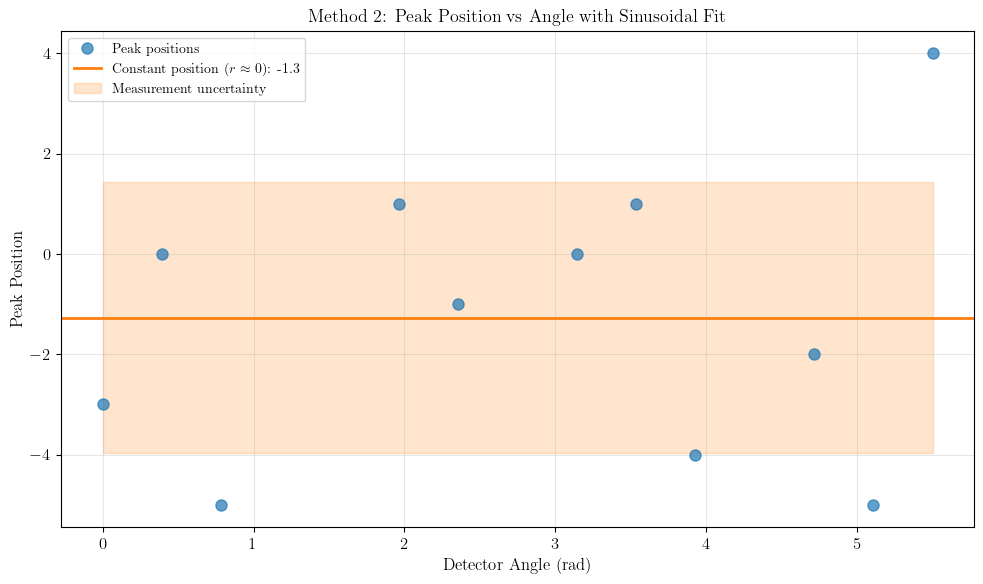


Fit Analysis:
──────────────────────────────────────────────────
Mean residual: -1.6149e-16
Std deviation: 2.6999
Max absolute: 5.2727


In [447]:
# Visualization: Peak Position vs Angle with sinusoidal fit
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data
ax.plot(detector_angles, peak_positions, 'o', markersize=8, 
        label='Peak positions', alpha=0.7, color='C0')

# Plot fitted curve
if popt is not None:
    angles_dense = np.linspace(np.min(detector_angles), np.max(detector_angles), 200)
    fitted_positions = sinusoidal_fit(angles_dense, fitted_amplitude, fitted_phase)
    
    if abs(fitted_amplitude) < perr[0]:
        # Signal at center: show horizontal line
        const_pos = np.mean(peak_positions)
        ax.axhline(const_pos, color='C1', linestyle='-', linewidth=2, 
                   label=f'Constant position ($r \\approx 0$): {const_pos:.1f}')
        ax.fill_between(angles_dense, const_pos - np.std(peak_positions), 
                        const_pos + np.std(peak_positions),
                        alpha=0.2, color='C1', label='Measurement uncertainty')
        residuals = peak_positions - const_pos
    else:
        ax.plot(angles_dense, fitted_positions, '-', linewidth=2, 
                label=f'Fit: {fitted_amplitude:.3f}·sin(θ+{fitted_phase:.3f})', color='C1')
        
        # Plot residuals as shaded region
        residuals = peak_positions - sinusoidal_fit(detector_angles, fitted_amplitude, fitted_phase)
        std_residual = np.std(residuals)
        ax.fill_between(angles_dense, 
                         sinusoidal_fit(angles_dense, fitted_amplitude, fitted_phase) - std_residual,
                         sinusoidal_fit(angles_dense, fitted_amplitude, fitted_phase) + std_residual,
                         alpha=0.2, color='C1', label=f'±1σ residual')

ax.set_xlabel('Detector Angle (rad)', fontsize=12)
ax.set_ylabel('Peak Position', fontsize=12)
ax.set_title('Method 2: Peak Position vs Angle with Sinusoidal Fit', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Print analysis
print(f"\nFit Analysis:")
print(f"─" * 50)
print(f"Mean residual: {np.mean(residuals):.4e}")
print(f"Std deviation: {np.std(residuals):.4f}")
print(f"Max absolute: {np.max(np.abs(residuals)):.4f}")